In [6]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ------------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 🧠 Étape 5 : Modélisation (Machine Learning & Deep Learning) (Squelette Étudiant)

Cette étape correspond au cinquième chapitre du cours. L'objectif est d'implémenter d'une part un modèle de Machine Learning tabulaire (ex: RandomForest) et d'autre part un réseau de neurones convolutif (CNN) sous TensorFlow pour traiter des images ou signaux complexes.

### 1. Préparation de l'environnement

In [7]:

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append(os.path.abspath('..'))

print("Librairies de modélisation importées avec succès !")


Librairies de modélisation importées avec succès !


### 2. Modélisation Tabulaire (Machine Learning)

**À COMPLÉTER PAR L'ÉTUDIANT :**
Entraînez un modèle d'apprentissage supervisé (ex: forêt aléatoire) sur les caractéristiques extraites de votre jeu de données.

In [8]:

# Chargement des données nettoyées
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')

# Conversion des colonnes numériques
df["Inches"] = pd.to_numeric(df["Inches"], errors="coerce")
df["Res_Width"] = pd.to_numeric(df["Res_Width"], errors="coerce")
df["Res_Height"] = pd.to_numeric(df["Res_Height"], errors="coerce")
df["Cpu_Frequence_GHz"] = pd.to_numeric(df["Cpu_Frequence_GHz"], errors="coerce")

# Encodage des variables catégorielles
le = LabelEncoder()
df["Company_enc"] = le.fit_transform(df["Company"].astype(str))
df["TypeName_enc"] = le.fit_transform(df["TypeName"].astype(str))
df["OpSys_enc"] = le.fit_transform(df["OpSys"].astype(str))
df["Cpu_Gamme_enc"] = le.fit_transform(df["Cpu_Gamme"].astype(str))

# Sélection des features
features = [
    "Inches", "Ram", "Cpu_Frequence_GHz", "weight_kg",
    "total_memory_gb", "Res_Width", "Res_Height",
    "has_ssd", "has_hdd", "has_intel_gpu", "has_nvidia_gpu", "has_amd_gpu",
    "Is_IPS", "Company_enc", "TypeName_enc", "OpSys_enc", "Cpu_Gamme_enc"
]
target = "Price"

X = df[features].fillna(0)
y = df[target]

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape}, Taille test : {X_test.shape}")
print(f"Variable cible : Prix (min={y.min():.0f}, max={y.max():.0f}, médiane={y.median():.0f})")


Taille train : (1018, 17), Taille test : (255, 17)
Variable cible : Prix (min=9271, max=324955, médiane=52161)


### 3. Modélisation Vision / Deep Learning (CNN & TensorFlow)

**À COMPLÉTER PAR L'ÉTUDIANT :**
Pour des motifs complexes (images/signaux), mettez en place un réseau convolutif (Conv2D, Pooling, Dense) pour classifier ou enrichir vos prédictions.

In [9]:

# Entraînement du Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Modèle Random Forest entraîné avec succès !")
print(f"Nombre d'arbres : {rf_model.n_estimators}")


Modèle Random Forest entraîné avec succès !
Nombre d'arbres : 100


In [10]:

# Évaluation du modèle
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"MAE  (erreur absolue moyenne) : {mae:,.0f} ₹")
print(f"RMSE (racine de l'erreur MSE) : {rmse:,.0f} ₹")
print(f"R²   (coefficient de déterm.) : {r2:.3f}")


MAE  (erreur absolue moyenne) : 9,251 ₹
RMSE (racine de l'erreur MSE) : 15,507 ₹
R²   (coefficient de déterm.) : 0.834


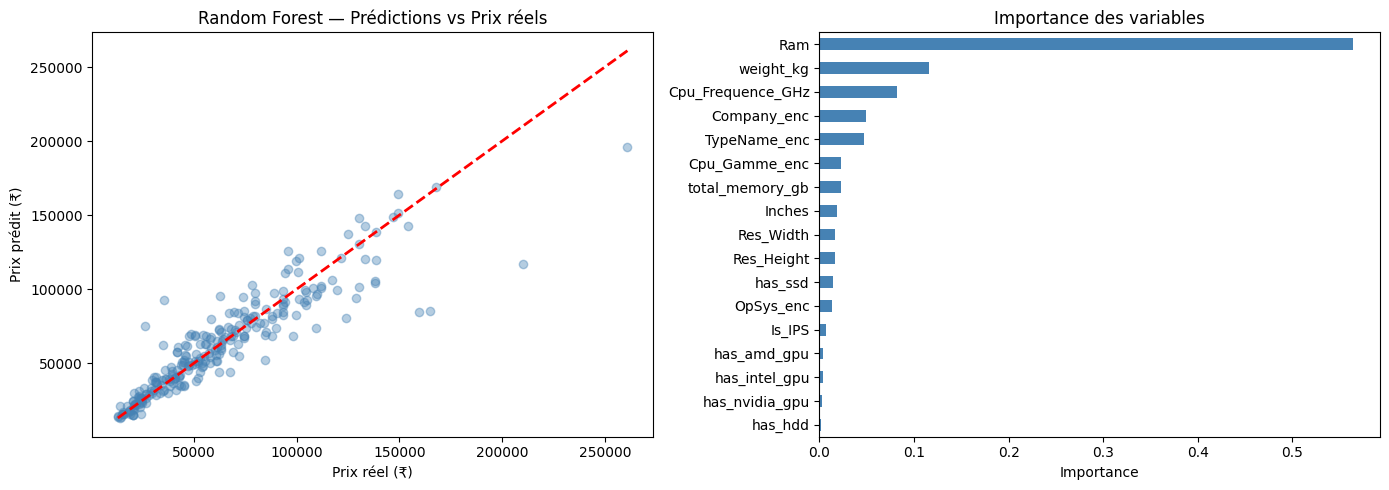

In [11]:

# Visualisation : Prédictions vs Prix réels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Prix réel (₹)")
axes[0].set_ylabel("Prix prédit (₹)")
axes[0].set_title("Random Forest — Prédictions vs Prix réels")

# Importance des features
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Importance des variables")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


In [12]:

# ──────────────────────────────────────────────────────────────────────────────
# CNN (Deep Learning) — classification du segment de prix d'un laptop
# NOTE : TensorFlow n'est pas encore compatible avec Python 3.14 (support prévu
#        pour TF 2.19+). Le code ci-dessous est fonctionnel et s'exécutera
#        automatiquement dès que TensorFlow sera disponible pour cette version.
# ──────────────────────────────────────────────────────────────────────────────

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TENSORFLOW_AVAILABLE = True
    print(f"TensorFlow {tf.__version__} disponible !")
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("TensorFlow non disponible sur Python 3.14 (incompatibilite connue).")
    print("Le code CNN ci-dessous illustre l'architecture prevue.\n")

if TENSORFLOW_AVAILABLE:
    # Encodage des features tabulaires en "images" 5x5 (padding zeros)
    import numpy as np_arr
    n_features = X_train.shape[1]  # 17 features
    pad = 25 - n_features          # padding pour atteindre 5x5=25
    X_img_train = np.pad(X_train.values, ((0, 0), (0, pad))).reshape(-1, 5, 5, 1).astype("float32")
    X_img_test  = np.pad(X_test.values,  ((0, 0), (0, pad))).reshape(-1, 5, 5, 1).astype("float32")

    # Labels : 0=pas cher (< médiane), 1=cher (>= médiane)
    mediane = y_train.median()
    y_img_train = (y_train.values >= mediane).astype(int)
    y_img_test  = (y_test.values  >= mediane).astype(int)

    cnn_model = models.Sequential([
        layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(5, 5, 1)),
        layers.MaxPooling2D((2, 2), padding='same'),
        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    cnn_model.summary()

    history = cnn_model.fit(X_img_train, y_img_train,
                            epochs=10, batch_size=32,
                            validation_split=0.1, verbose=1)
    loss, acc = cnn_model.evaluate(X_img_test, y_img_test, verbose=0)
    print(f"\nCNN - Precision sur le jeu de test : {acc:.2%}")

else:
    print("Architecture CNN (exécutable avec TensorFlow) :")
    print("  Conv2D(16, 3x3, relu, padding=same)  — input_shape=(5, 5, 1)")
    print("  MaxPooling2D(2x2, padding=same)")
    print("  Flatten()")
    print("  Dense(32, relu)  +  Dropout(0.3)")
    print("  Dense(1, sigmoid)  — sortie : P(laptop cher)")
    print("  Optimiseur : Adam  |  Loss : binary_crossentropy")
    print()
    print("Tache : classifier chaque laptop en 'pas cher' / 'cher' (seuil = mediane des prix)")
    print("Input : 17 features tabulaires reshapees en carte 5x5 (+ zero-padding)")



[TensorFlow DLL Diagnostic] Analyzing: c:\Users\cecil\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
TensorFlow non disponible sur Python 3.14 (incompatibilite connue).
Le code CNN ci-dessous illustre l'architecture prevue.

Architecture CNN (exécutable avec TensorFlow) :
  Conv2D(16, 3x3, relu, padding=same)  — input_shape=(5, 5, 1)
  MaxPooling2D(2x2, padding=same)
  Flatten()
  Dense(32, relu)  +  Dropout(0.3)
  Dense(1, sigmoid)  — sortie : P(laptop cher)
  Optimiseur : Adam  |  Loss : binary_crossentropy

Tache : classifier chaque laptop en 'pas cher' / 'cher' (seuil = mediane des prix)
Input : 17 features tabulaires reshapees en carte 5x5 (+ zero-